# Mestrado em Informática
## Aprendizagem Máquina
Ano letivo 2025/26 - Trabalho Prático 2

**Miguel de Campos Rodrigues - 27089**

O objetivo deste trabalho é utilizar algoritmos de classificação para treinar modelos preditivos da situação académica de estudantes de cursos de Licenciatura do Instituto Politécnico de Portalegre.  O conjunto de dados anonimizados encontra-se no ficheiro **dataset_PIAES_reduced.xlsx**.

As características presentes no conjunto de dados dizem respeito a uma parte da informação existente sobre os estudantes no ato da matrícula, nomeadamente:
`Sexo` (M/F)
`Estado civil` (desc)
`Ordem de ingresso` (opção de preferência de ingresso no curso – 1 representa 1ª opção)
`Curso` (desc)
`Deslocado` (S/N)
`Nacionalidade` (desc)
`Habilitação literária mãe` (desc)
`Situação profissional mãe` (desc)
`Situação profissional pai` (desc)
`Nota ingresso`
`Bolseiro` (1 para detentor de bolsa, 0 para o caso contrário)
`Idade no ingresso`

O campo Categoria tem como valores possíveis Diplomado / Não Diplomado e indica se o estudante obteve ou não o seu diploma ao fim de N anos de frequência do curso de Licenciatura. N representa a duração de um ciclo de estudos, e tem valor 4 para a Licenciatura em Enfermagem, valor 3 para todos os outros cursos de Licenciatura do IPP.

Na categoria “Não Diplomado” estão incluídos os estudantes que, estando inscritos, ainda não terminaram os seus cursos ao fim de N anos, e também os estudantes que abandonaram o curso ao longo do seu percurso académico.

Pretende-se, portanto, treinar modelos de aprendizagem máquina com o objetivo de prever, o mais cedo possível no percurso académico dos estudantes, a sua situação ao fim de N anos.

Aspetos a ter em conta no desenvolvimento do trabalho:
<ol type="A">
  <li>Pré-processamento dos dados, justificando as opções adotadas.</li>
  <li>Treino/ teste de modelos e otimização de parâmetros para os algoritmos de classificação estudados (incluindo regressão logística, k vizinhos mais próximos, máquinas de vetor de suporte, árvores de decisão, florestas aleatórias e redes neuronais).</li>
  <li>Análise da importância das características.</li>
  <li>Comparação dos modelos treinados e eleição justificada do(s) modelo(s) mais adequado(s).</li>
</ol>

O trabalho deve ser entregue pelo PAE no formato Jupyter Lab (*.ipynb), com o código, as justificações e a discussão final.

In [14]:
# from google.colab import drive
# drive.mount('/content/drive')

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, RobustScaler, StandardScaler
from sklearn.svm import SVC

%matplotlib inline
sns.set_style("whitegrid")

Primeiro iremos ler carregar o dataset.

In [16]:
df=pd.read_excel("dataset_PIAES_reduced.xlsx")
print("Shape:", df.shape)
df.columns

Shape: (5742, 13)


Index(['Sexo (M/F)', 'Estado civil (desc)', 'Ordem de ingresso',
       'Curso (desc)', 'Deslocado (S/N)', 'Nacionalidade (desc)',
       'Habilitação literária mãe (desc)', 'Situação profissional mãe (desc)',
       'Situação profissional pai (desc)', 'Nota ingresso', 'Bolseiro',
       'Idade no ingresso', 'Categoria'],
      dtype='object')

### A. Processamento de dados

O dataset contém 5742 registos e 13 colunas. Com base na análise feita na unidade curricular de Programação de Ciência de Dados será feito o mesmo tratamento de dados:

1. Remoção de outliers na nota de ingresso
2. Imputação de dados nulos
3. Normalização das habilitações literárias da mãe.
4. Criação de colunas extras:
   1. Escola
   2. Curso
   2. Nr. anos de curso
   3. Família de Risco
   4. Indicadores geodemoráficos
5. Numeração de classificadores

In [17]:
# mapas de categorias (hard coded)
habilitacoes = {
    "Sem escolaridade obrigatória": [
        "Sabe ler sem possuir o 4º ano de escolaridade",
        "Não sabe ler nem escrever"
    ],
    "Ensino Básico 2º Ciclo (6º/7º/8º Ano) ou Equiv.": [
        "7º Ano de Escolaridade",
        "9º Ano de Escolaridade - Não Concluído",
        "7º Ano (Antigo)", "8º Ano de Escolaridade"
    ],
    "Ensino Básico 3º Ciclo (9º/10º/11º Ano) ou Equiv.": [
        "Curso Geral de Administração e Comércio",
        "Outro - 11º Ano de Escolaridade",
        "11º Ano de Escolaridade - Não Concluído",
        "10º Ano de Escolaridade",
        "12º Ano de Escolaridade - Não Concluído",
        "Curso Geral de Comércio",
        "Curso Complementar Liceal - Não Concluído"
    ],
    "Ensino Secundário (12º Ano) ou Equiv.": [
        'Curso Técnico-Profissional',
        'Curso Complementar Liceal',
        '2ª Ciclo do Curso Geral Liceal',
        'Complementar de Contabilidade e Administração',
        '2º Ano Curso Complementar Liceal'
    ],

    "Cursos superiores ou de especialização (QEQ Nível 5)": [
        "Curso de Especialização Tecnológica",
        "Curso Técnico Superior Profissional",
        "Curso de Estudos Superiores Especializados",
        "Frequência do Ensino Superior",
    ],

    "Ensino Superior - Licenciatura":[
        "Ensino Superior - Licenciatura (1º ciclo)"
    ],

    "Ensino Superior - Mestrado": [
        "Ensino Superior - Mestrado (2º ciclo)"
    ],

    "Ensino Superior - Doutoramento": [
        "Ensino Superior - Doutoramento (3º ciclo)"
    ]
}

ordered_hab = [
    'Desconhecido',
    'Sem escolaridade obrigatória',
    'Ensino Básico 1º Ciclo (4º/5º Ano) ou Equiv.',
    'Ensino Básico 2º Ciclo (6º/7º/8º Ano) ou Equiv.',
    'Ensino Básico 3º Ciclo (9º/10º/11º Ano) ou Equiv.',
    'Ensino Secundário (12º Ano) ou Equiv.',
    'Cursos superiores ou de especialização (QEQ Nível 5)',
    'Ensino Superior - Licenciatura',
    'Ensino Superior - Bacharelato',
    'Ensino Superior - Mestrado',
    'Ensino Superior - Doutoramento',
]

rendimento_estavel = [
    "Trabalhador(a) por Conta Própria como Isolado",
    "Trabalhador(a) por Conta Própria como Empregador",
    "Trabalhador(a) por Conta de Outrém",
    "Serviço Militar"
]

origem_acordo = ["Portuguesa", "Brasileira", "Guineense", "Santomense", "Caboverdeana", "Angolana", "Moçambicana"]
origem_ue = ["Portuguesa", "Espanhola", "Romena", "Italiana", "Alemã", "Holandesa", "Bulgara", "Lituana"]
origem_america = ["Brasileira", "Mexicana", "Cubana", "Uruguai"]
origem_euroasiatica = ["Portuguesa", "Espanhola", "Ucraniana", "Romena", "Italiana",
                    "Moldova (República de)", "Alemã", "Russa", "Holandesa", "Turca", "Bulgara",
                    "Inglesa", "Lituana"]
origem_africana = ["Guineense", "Santomense", "Caboverdeana", "Angolana", "Moçambicana"]

escolas = {
    'ESS - Escola Superior de Saúde': [
        'Enfermagem',
        'Higiene Oral',
    ],
    'ESTGD - Escola Superior de Tecnologias, Gestão e Design': [
        'Gestão',
        'Gestão (pós-laboral)',
        'Administração de Publicidade e Marketing',
        'Design de Animação e Multimédia',
        'Engenharia Informática',
        'Design de Comunicação',
        'Tecnologias de Produção de Biocombustíveis',
    ],
    'ESECS - Escola Superior de Educação e Ciencias Sociais': [
        'Turismo',
        'Jornalismo e Comunicação',
        'Serviço Social',
        'Serviço Social (pós-laboral)',
        'Educação Básica',
    ],
    'ESBE - Escola Superior de Biociências de Elvas': [
        'Agronomia',
        'Equinicultura',
        'Enfermagem Veterinária',
    ]
}

In [ ]:
def remove_outliers():
  global df
  df = df[df["Nota ingresso"] >= 95]
  df = df[df["Nota ingresso"] < 200]

def impute_null_values():
  global df
  median_imputer = SimpleImputer(strategy='median')
  common_imputer = SimpleImputer(strategy='most_frequent')

  df_num = df.select_dtypes(include='number')
  df_num_imp = pd.DataFrame(
      median_imputer.fit_transform(df_num),
      columns=df_num.columns,
      index=df.index)

  df_hab_mae = df[['Habilitação literária mãe (desc)']]
  df_hab_mae_imp = pd.DataFrame(
      common_imputer.fit_transform(df_hab_mae),
      columns=df_hab_mae.columns,
      index=df.index)

  df[df_num_imp.columns] = df_num_imp
  df[df_hab_mae_imp.columns] = df_hab_mae_imp

def normalize_mother_degree():
  global df
  # Habilitação literária mãe (desc)
  col_hab = "Habilitação literária mãe (desc)"
  col_hab_class = "Habilitação literária mãe (classe)"

  for key, items in habilitacoes.items():
      df.loc[df[col_hab].isin(items), col_hab] = key


  for i, habilitacao in enumerate(ordered_hab):
      mask = df[col_hab] == habilitacao
      df.loc[mask, col_hab_class] = i

def normalize_school():
  global df
  # Escolas
  # col_escola_desc = "Escola (desc)"
  col_escola_class = "Escola (classe)"
  col_curso_desc = "Curso (desc)"

  for i, (escola, cursos) in enumerate(escolas.items()):
      curso_mask = df[col_curso_desc].isin(cursos)
      # df.loc[curso_mask, col_escola_desc] = escola
      df.loc[curso_mask, col_escola_class] = i

def normalize_courses():
  global df
  # Curso (desc), Estado civil (desc), Situação profissional mãe (desc), Situação profissional pai (desc)
  query_cols = [
      'Curso (desc)',
      'Estado civil (desc)',
      'Situação profissional mãe (desc)',
      'Situação profissional pai (desc)',
      'Nacionalidade (desc)']
  novas_cols = [
      'Curso (classe)',
      'Estado civil (classe)',
      'Situação profissional mãe (classe)',
      'Situação profissional pai (classe)',
      'Nacionalidade (classe)']

  for col, new_col in zip(query_cols, novas_cols):
      le = LabelEncoder()
      df[new_col] = le.fit_transform(df[col])

def binary_indicators():
  global df
  # indicadores binários OneHotEncoder
  ohe=OneHotEncoder(sparse_output=False, drop="first")
  query_cols = ["Sexo (M/F)", "Deslocado (S/N)", "Categoria"]
  new_vals = ohe.fit_transform(df[query_cols])
  new_cols = ohe.get_feature_names_out()

  df_ohe = pd.DataFrame(new_vals, columns = new_cols, index = df.index)
  df = pd.concat([df, df_ohe], axis=1)



  df['Família de risco'] = (
      ~df['Situação profissional mãe (desc)'].isin(rendimento_estavel) &
      ~df['Situação profissional pai (desc)'].isin(rendimento_estavel)
  ).astype(int)

  df['Origem de país de acordo ortográfico'] = df['Nacionalidade (desc)'].isin(origem_acordo).astype(int)
  df['Origem de país da UE'] = df['Nacionalidade (desc)'].isin(origem_ue).astype(int)
  df['Origem de país do continente americano'] = df['Nacionalidade (desc)'].isin(origem_america).astype(int)
  df['Origem de país estrangeiro'] = (df['Nacionalidade (desc)'] != "Portuguesa").astype(int)
  df['Origem de país do continente euroásiatico'] = df['Nacionalidade (desc)'].isin(origem_euroasiatica).astype(int)
  df['Origem de país do continente africano'] = df['Nacionalidade (desc)'].isin(origem_africana).astype(int)

def numeric_indicators():
  global df
  # indicadores numéricos
  df['Nr. anos de curso'] = (df['Curso (classe)'] == 5).astype(int) + 3
  #  df['Nota ingresso (Norm)'] = StandardScaler().fit_transform(df[['Nota ingresso']])
  #  df['Idade no ingresso (Norm)'] = RobustScaler().fit_transform(df[['Nota ingresso']])

def drop_redundant_columns():
  global df
  df = df.drop(['Sexo (M/F)', 'Estado civil (desc)',
       'Curso (desc)', 'Deslocado (S/N)', 'Nacionalidade (desc)',
       'Habilitação literária mãe (desc)', 'Situação profissional mãe (desc)',
       'Situação profissional pai (desc)', 'Categoria'], axis=1)`

In [ ]:
remove_outliers()
impute_null_values()
normalize_mother_degree()
normalize_school()
normalize_courses()
numeric_indicators()
binary_indicators()
drop_redundant_columns()
padronize_columns()

df.columns

Index(['Ordem de ingresso', 'Nota ingresso', 'Bolseiro', 'Idade no ingresso',
       'Habilitação literária mãe (classe)', 'Escola (classe)',
       'Curso (classe)', 'Estado civil (classe)',
       'Situação profissional mãe (classe)',
       'Situação profissional pai (classe)', 'Nacionalidade (classe)',
       'Nr. anos de curso', 'Sexo (M/F)_M', 'Deslocado (S/N)_S',
       'Categoria_Não Diplomado', 'Família de risco',
       'Origem de país de acordo ortográfico', 'Origem de país da UE',
       'Origem de país do continente americano', 'Origem de país estrangeiro',
       'Origem de país do continente euroásiatico',
       'Origem de país do continente africano'],
      dtype='object')

In [20]:
df

,Ordem de ingresso,Nota ingresso,Bolseiro,Idade no ingresso,Habilitação literária mãe (classe),Escola (classe),Curso (classe),Estado civil (classe),Situação profissional mãe (classe),Situação profissional pai (classe),...,Sexo (M/F)_M,Deslocado (S/N)_S,Categoria_Não Diplomado,Família de risco,Origem de país de acordo ortográfico,Origem de país da UE,Origem de país do continente americano,Origem de país estrangeiro,Origem de país do continente euroásiatico,Origem de país do continente africano
0,5.0,127.3,0.0,20.0,4.0,1.0,2,4,9,4,...,1.0,1.0,1.0,0,1,1,0,0,1,0
1,1.0,142.5,0.0,19.0,7.0,2.0,16,4,9,10,...,1.0,1.0,0.0,0,1,1,0,0,1,0
2,5.0,124.8,0.0,19.0,2.0,1.0,3,4,9,2,...,1.0,1.0,1.0,0,1,1,0,0,1,0
3,2.0,119.6,0.0,20.0,2.0,2.0,12,4,9,10,...,0.0,1.0,0.0,0,1,1,0,0,1,0
4,1.0,141.5,0.0,45.0,3.0,2.0,14,0,5,5,...,0.0,0.0,0.0,1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5737,2.0,119.0,0.0,18.0,5.0,2.0,12,4,7,10,...,0.0,1.0,1.0,0,0,0,0,1,1,0
5738,1.0,116.0,1.0,20.0,5.0,0.0,5,4,9,10,...,0.0,0.0,0.0,0,1,1,0,0,1,0
5739,1.0,149.5,1.0,30.0,2.0,0.0,5,4,5,2,...,0.0,1.0,1.0,1,1,1,0,0,1,0
5740,1.0,153.8,1.0,20.0,2.0,1.0,9,4,9,10,...,0.0,1.0,0.0,0,1,1,0,0,1,0


### B. Modelos e otimização de parâmetros
#### Treino/teste de modelos

O modelo será dividido em dois subconjuntos de testes e treino (80/20):

In [21]:
X = df.drop(["Categoria_Não Diplomado"], axis=1)
y = df["Categoria_Não Diplomado"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train: (4537, 21)
X_test: (1135, 21)
y_train (4537,)
y_test (1135,)


#### Escalamento de variáveis
Uma vez que os algoritmos SVM implicam o cálculo de distâncias, vamos padronizar os dados, à semelhança do que foi feito no tutorial anterior. Usamos o `RobustScaler`:

In [22]:
RScaler = RobustScaler()
Xtrain_RScl = pd.DataFrame(RScaler.fit_transform(X_train),
                           columns=X_train.columns,
                           index= X_train.index)
Xtest_RScl = pd.DataFrame(RScaler.transform(X_test),
                          columns = X_test.columns,
                          index = X_test.index)

Xtrain_RScl.head()

,Ordem de ingresso,Nota ingresso,Bolseiro,Idade no ingresso,Habilitação literária mãe (classe),Escola (classe),Curso (classe),Estado civil (classe),Situação profissional mãe (classe),Situação profissional pai (classe),...,Nr. anos de curso,Sexo (M/F)_M,Deslocado (S/N)_S,Família de risco,Origem de país de acordo ortográfico,Origem de país da UE,Origem de país do continente americano,Origem de país estrangeiro,Origem de país do continente euroásiatico,Origem de país do continente africano
5026,0.0,0.494253,0.0,1.0,0.000000,2.0,-0.750,0.0,-1.75,0.0,...,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1086,0.0,-0.643678,0.0,-0.2,0.333333,0.0,0.250,0.0,0.00,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
727,0.0,0.270115,0.0,-0.4,-0.333333,2.0,0.125,0.0,0.00,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4160,0.0,1.396552,0.0,0.4,0.000000,0.0,0.000,0.0,0.00,-1.0,...,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
677,0.0,0.390805,0.0,0.0,-0.666667,1.0,0.750,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,1.0,-1.0,1.0


#### Otimização de parâmetros

In [23]:
#Data frame para registo de performance
performance = pd.DataFrame(columns=['Train Accuracy','Test Accuracy', "Test f1"])

In [ ]:
rotulos=["Diplomado", "Não diplomado"]

def model_evaluation(acc_train, verdadeiros, previstos,  titulo):
  ''' Função que cria e imprime a
    matriz de confusão de um dados modelo e respetivo relatório de classificação
    preenche o df classification report
    verdadeiros - rotulos verdadeiros do conjunto de teste
    previstos - rotulos previstos pelo modelo no conjunto de teste
    acc_train - exatidão do modelo no conjunto de treino, calculada previamente
    titulo - nome do modelo
  '''
  conf_matrix =  confusion_matrix(verdadeiros, previstos,  normalize="true")
  s = sns.heatmap(conf_matrix, annot=True, cmap="Greens",
              xticklabels=rotulos, yticklabels=rotulos)
  s.set(xlabel = "Rótulo Previsto", ylabel="Rótulo Verdadeiro", title=titulo)
  plt.show()
  print(classification_report(verdadeiros, previstos))
  #preencher DF com resumo da performance
  #Avaliar o modelo com a exatidão


  acc_test= accuracy_score(verdadeiros, previstos)
  f1 = f1_score(verdadeiros, previstos, average="macro" )

  performance.loc[titulo,
                  ['Train Accuracy','Test Accuracy', "Test f1"]] =[
                  '{0:.2f}'.format(acc_train),
                  '{0:.2f}'.format(acc_test),
                  '{0:.2f}'.format(f1)]

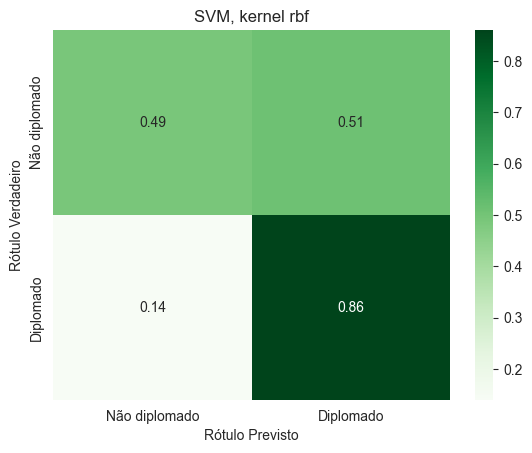

              precision    recall  f1-score   support

         0.0       0.75      0.49      0.59       522
         1.0       0.66      0.86      0.75       613

    accuracy                           0.69      1135
   macro avg       0.71      0.68      0.67      1135
weighted avg       0.70      0.69      0.68      1135



,Train Accuracy,Test Accuracy,Test f1
"SVM, kernel rbf",0.70,0.69,0.67


In [28]:
svm_rbf = SVC(kernel = 'rbf')
svm_rbf.fit(Xtrain_RScl, y_train)
y_pred = svm_rbf.predict(Xtest_RScl)
acc_train = svm_rbf.score(Xtrain_RScl, y_train)

model_evaluation(acc_train, y_test, y_pred, "SVM, kernel rbf")
display(performance)

#### Regressão Polinomial

SVM, kernel linear


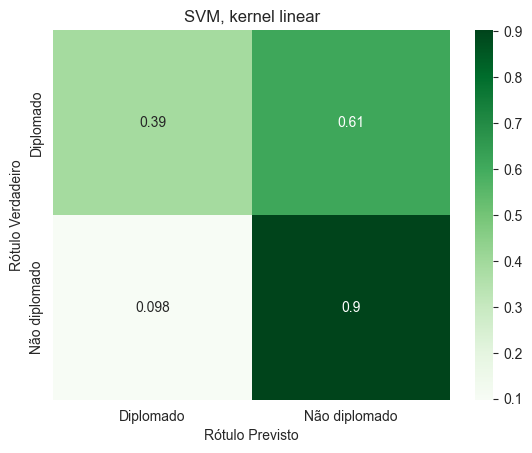

              precision    recall  f1-score   support

         0.0       0.77      0.39      0.52       522
         1.0       0.63      0.90      0.74       613

    accuracy                           0.67      1135
   macro avg       0.70      0.64      0.63      1135
weighted avg       0.70      0.67      0.64      1135

SVM, kernel poly, grau 2


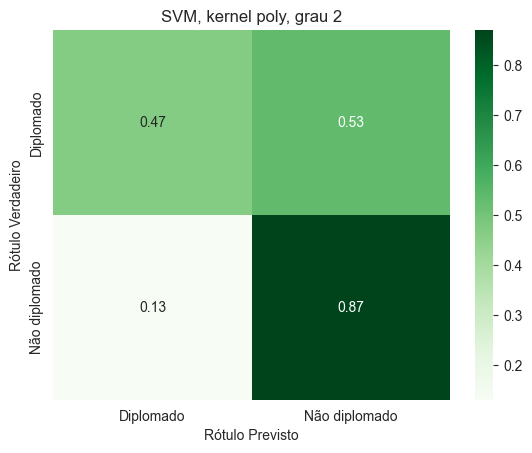

              precision    recall  f1-score   support

         0.0       0.75      0.47      0.58       522
         1.0       0.66      0.87      0.75       613

    accuracy                           0.68      1135
   macro avg       0.71      0.67      0.66      1135
weighted avg       0.70      0.68      0.67      1135

SVM, kernel poly, grau 3


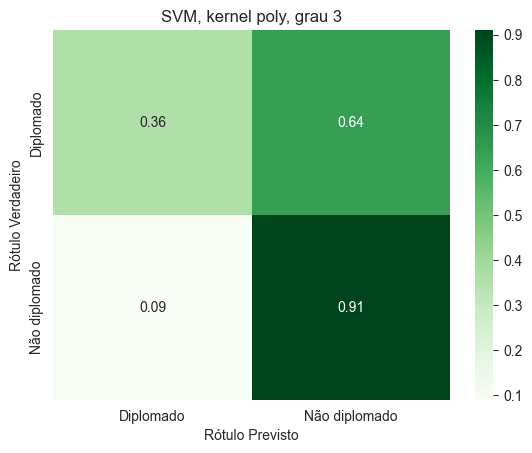

              precision    recall  f1-score   support

         0.0       0.77      0.36      0.49       522
         1.0       0.62      0.91      0.74       613

    accuracy                           0.66      1135
   macro avg       0.70      0.63      0.61      1135
weighted avg       0.69      0.66      0.62      1135

SVM, kernel rbf


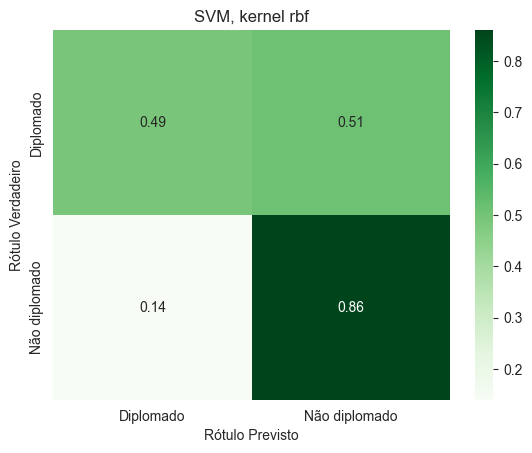

              precision    recall  f1-score   support

         0.0       0.75      0.49      0.59       522
         1.0       0.66      0.86      0.75       613

    accuracy                           0.69      1135
   macro avg       0.71      0.68      0.67      1135
weighted avg       0.70      0.69      0.68      1135

SVM, kernel sigmoid


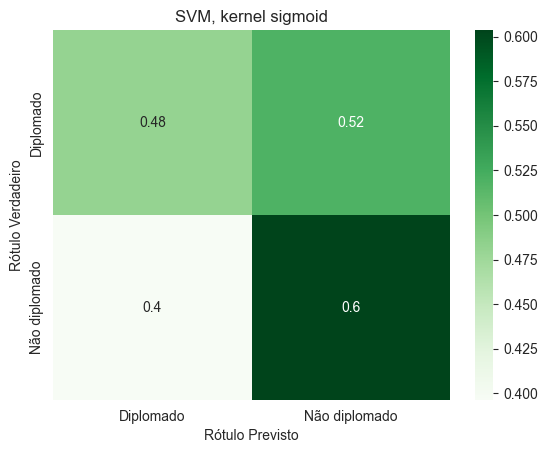

              precision    recall  f1-score   support

         0.0       0.51      0.48      0.49       522
         1.0       0.58      0.60      0.59       613

    accuracy                           0.55      1135
   macro avg       0.54      0.54      0.54      1135
weighted avg       0.55      0.55      0.55      1135



,Train Accuracy,Test Accuracy,Test f1
"SVM, kernel rbf",0.70,0.69,0.67
"SVM, kernel linear",0.67,0.67,0.63
"SVM, kernel poly, grau 2",0.69,0.68,0.66
"SVM, kernel poly, grau 3",0.68,0.66,0.61
"SVM, kernel sigmoid",0.57,0.55,0.54


In [32]:
kernel =['linear', 'poly', 'rbf', 'sigmoid']
for k in kernel:
  if  k == 'poly':
    for i in range(2, 4): #testar polinomial com grau 2 e 3
      nome = f"SVM, kernel {k}, grau {i}"
      print(nome)
      svm = SVC(kernel = k, degree=i)
      svm.fit(Xtrain_RScl, y_train)
      ypred_test=svm.predict(Xtest_RScl)
      acc_score=svm.score(Xtrain_RScl, y_train)
      model_evaluation(acc_score, y_test, ypred_test, nome)
  else:
      nome = f"SVM, kernel {k}"
      print(nome)
      svm = SVC(kernel = k)
      svm.fit(Xtrain_RScl, y_train)
      ypred_test=svm.predict(Xtest_RScl)
      acc_score=svm.score(Xtrain_RScl, y_train)
      model_evaluation(acc_score, y_test, ypred_test, nome)

display(performance)
